In [27]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
from astropy.io import fits

from astropy import wcs

In [28]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [29]:
field = 'south'
brickname = '2361p025'

coadd_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/coadd/{}/{}'.format(field, brickname[:3], brickname)
metrics_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/metrics/{}'.format(field, brickname[:3])

vranges = {'g':0.015, 'r':0.03, 'z':0.05, 'W1':15, 'W2':40}

In [43]:
band = 'W1'
vrange = vranges[band]

img_path = glob.glob(os.path.join(coadd_dir, '*-image-{}.fits.fz'.format(band)))[0]
model_path = glob.glob(os.path.join(coadd_dir, '*-model-{}.fits.fz'.format(band)))[0]
maskbits_path = glob.glob(os.path.join(coadd_dir, '*-maskbits.fits.fz'))[0]

img = fitsio.read(img_path)
model = fitsio.read(model_path)
maskbits = fitsio.read(maskbits_path, ext='MASKBITS')
wisem1 = fitsio.read(maskbits_path, ext='WISEM1')

In [44]:
# Get MASKBITS values for WISE coadd pixels

hdulist = fits.open(img_path)
hdulist_grz = fits.open(maskbits_path)
w_wise = wcs.WCS(hdulist[1].header)
w_grz = wcs.WCS(hdulist_grz[1].header)
naxis1 = hdulist[1].header['NAXIS1']  # Length of the *second* index of the 2-D array
naxis2 = hdulist[1].header['NAXIS2']  # Length of the *first* index of the 2-D array

# The RA/DEC 2-D array for the image
pix_x_grid, pix_y_grid = np.meshgrid(np.arange(naxis1), np.arange(naxis2))
pix_ra, pix_dec = w_wise.wcs_pix2world(pix_x_grid, pix_y_grid, 0)

pix_x, pix_y = w_grz.wcs_world2pix(pix_ra, pix_dec, 0)
pix_x, pix_y = np.round(pix_x).astype(int), np.round(pix_y).astype(int)
maskbits_wise = maskbits[pix_y, pix_x]  # pix_y is the *first* index
maskbits_wise = (maskbits_wise & 2**8 > 0)

wisem1_wise = wisem1[pix_y, pix_x]  # pix_y is the *first* index

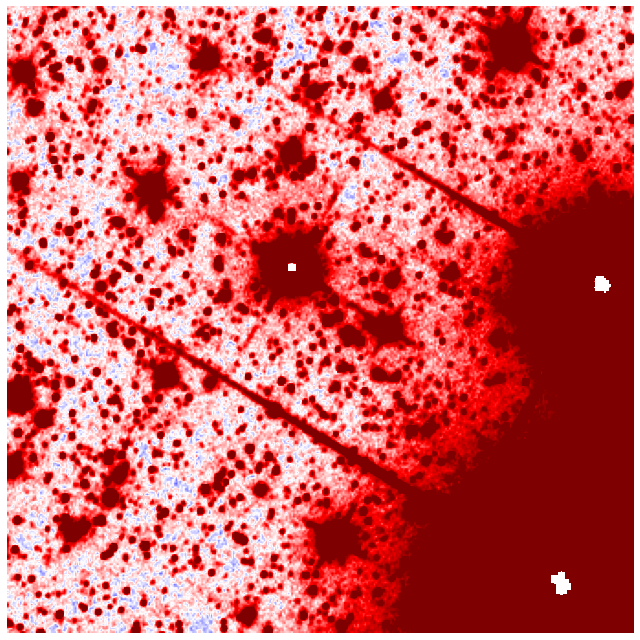

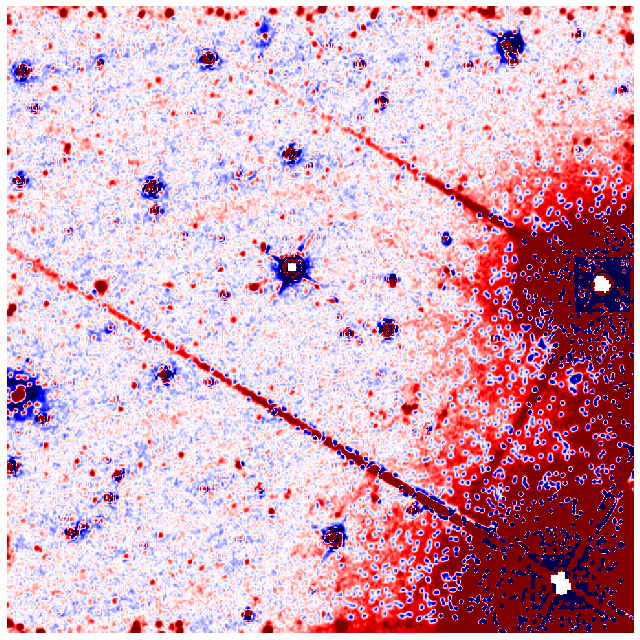

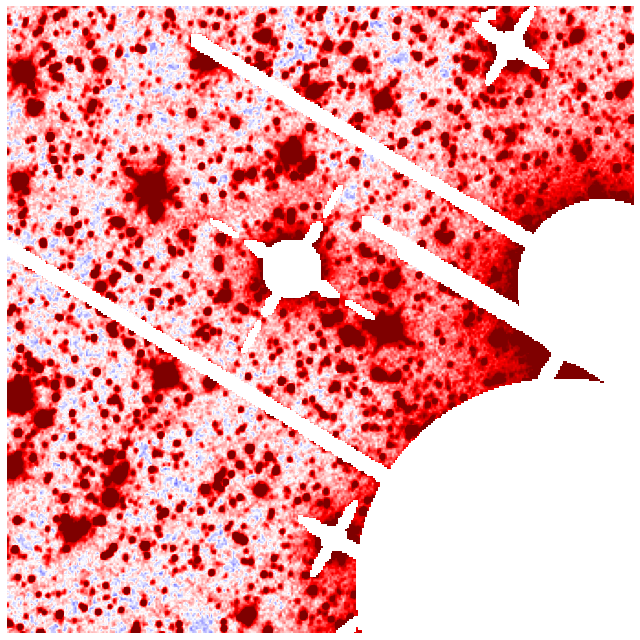

In [45]:
plt.figure(figsize=(9, 9))
fig = plt.imshow(img, cmap='seismic', vmin=-vrange, vmax=vrange, origin='lower')
plt.axis('off')
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)
plt.tight_layout()
# plt.savefig('coadd_plots/{}_{}_img.png'.format(brickname, band))
plt.show()

plt.figure(figsize=(9, 9))
fig = plt.imshow(img-model, cmap='seismic', vmin=-vrange, vmax=vrange, origin='lower')
plt.axis('off')
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)
plt.tight_layout()
# plt.savefig('coadd_plots/{}_{}_resid.png'.format(brickname, band))
plt.show()

img1 = img.copy()
img1[maskbits_wise] = np.nan
plt.figure(figsize=(9, 9))
fig = plt.imshow(img1, cmap='seismic', vmin=-vrange, vmax=vrange, origin='lower')
plt.axis('off')
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)
plt.tight_layout()
# plt.savefig('coadd_plots/{}_{}_img-w1masked.png'.format(brickname, band))
plt.show()

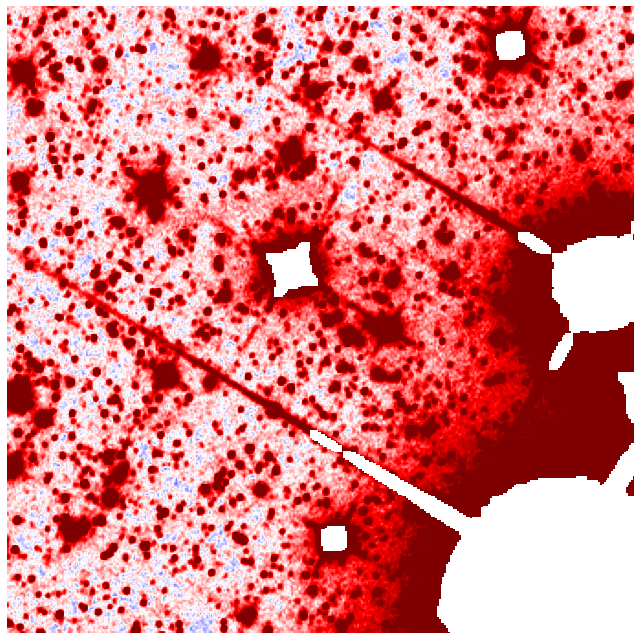

In [47]:
# WISEM1_BRIGHT
mask = wisem1_wise & 2**0 > 0

img1 = img.copy()
img1[mask] = np.nan
plt.figure(figsize=(9, 9))
fig = plt.imshow(img1, cmap='seismic', vmin=-vrange, vmax=vrange, origin='lower')
plt.axis('off')
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)
plt.tight_layout()
# plt.savefig('coadd_plots/{}_{}_img-w1masked.png'.format(brickname, band))
plt.show()

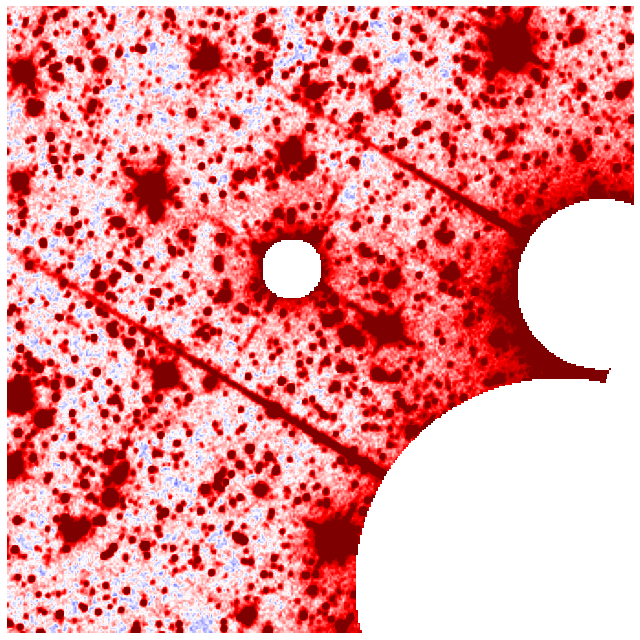

In [48]:
# WISEM1_HALO
mask = wisem1_wise & 2**5 > 0

img1 = img.copy()
img1[mask] = np.nan
plt.figure(figsize=(9, 9))
fig = plt.imshow(img1, cmap='seismic', vmin=-vrange, vmax=vrange, origin='lower')
plt.axis('off')
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)
plt.tight_layout()
# plt.savefig('coadd_plots/{}_{}_img-w1masked.png'.format(brickname, band))
plt.show()

-------

In [7]:
bricks = Table(fitsio.read('/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/south/survey-bricks-dr9-south.fits.gz'))

(360.0, 0.0, -30.0, 45.0)

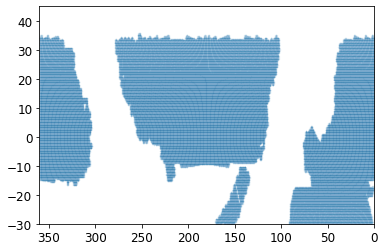

In [8]:
mask = np.full(len(bricks), True)
plt.plot(bricks['ra'][mask], bricks['dec'][mask], '.', alpha=0.1, ms=1)
plt.axis([360, 0, -30, 45])

In [9]:
tt = Table(fitsio.read('/global/u2/r/rongpu/temp/data/wise1.fits'))

Doubly matched objects = 2946
Final matched objects = 1425


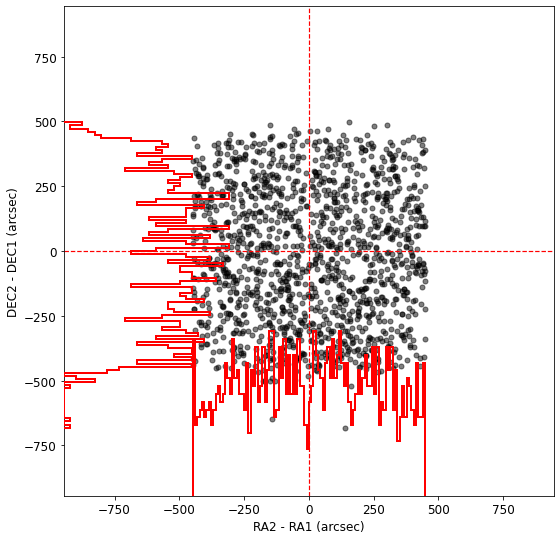

In [16]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(tt['RA'], tt['DEC'], bricks['ra'], bricks['dec'], search_radius=3600*0.25, plot_q=True)

In [19]:
tt = tt[idx1]
bricks = bricks[idx2]

In [23]:
idx = np.random.choice(len(bricks), size=20, replace=False)

for index in idx:

    field = 'south'
    brickname = bricks['brickname'][index]

    coadd_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/coadd/{}/{}'.format(field, brickname[:3], brickname)
    metrics_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/metrics/{}'.format(field, brickname[:3])

    band = 'W1'
    vrange = vranges[band]

    img_path = glob.glob(os.path.join(coadd_dir, '*-image-{}.fits.fz'.format(band)))[0]
    model_path = glob.glob(os.path.join(coadd_dir, '*-model-{}.fits.fz'.format(band)))[0]
    maskbits_path = glob.glob(os.path.join(coadd_dir, '*-maskbits.fits.fz'))[0]

    img = fitsio.read(img_path)
    model = fitsio.read(model_path)
    maskbits = fitsio.read(maskbits_path)

    # Get MASKBITS values for WISE coadd pixels

    hdulist = fits.open(img_path)
    hdulist_grz = fits.open(maskbits_path)
    w_wise = wcs.WCS(hdulist[1].header)
    w_grz = wcs.WCS(hdulist_grz[1].header)
    naxis1 = hdulist[1].header['NAXIS1']  # Length of the *second* index of the 2-D array
    naxis2 = hdulist[1].header['NAXIS2']  # Length of the *first* index of the 2-D array

    # The RA/DEC 2-D array for the image
    pix_x_grid, pix_y_grid = np.meshgrid(np.arange(naxis1), np.arange(naxis2))
    pix_ra, pix_dec = w_wise.wcs_pix2world(pix_x_grid, pix_y_grid, 0)

    pix_x, pix_y = w_grz.wcs_world2pix(pix_ra, pix_dec, 0)
    pix_x, pix_y = np.round(pix_x).astype(int), np.round(pix_y).astype(int)
    maskbits_wise = maskbits[pix_y, pix_x]  # pix_y is the *first* index
    maskbits_wise = (maskbits_wise & 2**8 > 0)


    vranges = {'g':0.015, 'r':0.03, 'z':0.05, 'W1':15, 'W2':40}
    plt.figure(figsize=(9, 9))
    fig = plt.imshow(img, cmap='seismic', vmin=-vrange, vmax=vrange, origin='lower')
    plt.axis('off')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    plt.tight_layout()
    plt.savefig('plots/{}_{}_img.png'.format(brickname, band))
    # plt.show()
    plt.close()

    plt.figure(figsize=(9, 9))
    fig = plt.imshow(img-model, cmap='seismic', vmin=-vrange, vmax=vrange, origin='lower')
    plt.axis('off')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    plt.tight_layout()
    plt.savefig('plots/{}_{}_resid.png'.format(brickname, band))
    # plt.show()
    plt.close()

    img1 = img.copy()
    img1[maskbits_wise] = np.nan
    plt.figure(figsize=(9, 9))
    fig = plt.imshow(img1, cmap='seismic', vmin=-vrange, vmax=vrange, origin='lower')
    plt.axis('off')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    plt.tight_layout()
    plt.savefig('plots/{}_{}_img-w1masked.png'.format(brickname, band))
    # plt.show()
    plt.close()